# 04 — Investigación: ¿hay patrones de fraude que el sistema actual no ve?

**Reto hackIAthon Aseguradora del Sur · sección 9 (Detección de anomalías)**

## Pregunta de investigación

> ¿Existen siniestros estadísticamente anómalos que el sistema actual (XGBoost supervisado + 7 reglas + 14 señales) **no** marca, y que podrían representar esquemas de fraude emergentes que el dataset histórico aún no contiene?

## Hipótesis testables

| H | Enunciado | Cómo lo validamos |
|---|-----------|-------------------|
| **H1** | Existe una cola multidimensionalmente rara que el supervisado no captura | Comparar marca XGB vs marca IsolationForest, medir solapamiento |
| **H2** | Los outliers correlacionan con la etiqueta de fraude > baseline | Lift = `P(fraude\|outlier) / P(fraude)` |
| **H3** | Diferentes algoritmos no supervisados convergen en un núcleo común | Calcular intersección entre IF, LOF, EllipticEnvelope; reportar Jaccard |
| **H4** | Las anomalías se concentran en combinaciones cobertura × sucursal | χ² de independencia |
| **H5** | El "subgrupo novedoso" (anómalo ∧ ¬etiqueta ∧ ¬xgb) tiene perfil distinto al fraude conocido | Comparar medianas y t-tests por feature |

## Plan de análisis (ciencia de datos rigurosa)

1. Carga, calidad de datos, faltantes, tipos
2. **EDA univariado**: distribuciones, normalidad, asimetría, outliers por variable
3. **EDA multivariado**: matriz de correlación, asociaciones cobertura↔fraude, sucursal↔fraude
4. **Baseline naive**: detección univariada de outliers (IQR, z-score)
5. **Anomaly detection multivariado**: 3 algoritmos en paralelo (IsolationForest, Local Outlier Factor, Elliptic Envelope)
6. **Consenso y discordancia** entre algoritmos
7. **Validación** vs etiqueta y vs XGBoost (cumple H1, H2, H3)
8. **Análisis del subgrupo novedoso** (H5)
9. **Análisis de concentración** por sucursal y cobertura (H4)
10. **Sensitivity analysis**: cómo cambian los hallazgos al variar hiperparámetros
11. **Limitaciones, sesgos y trabajo futuro**
12. **Decisión operativa** y métrica para el pitch

## 1. Setup, carga y calidad de datos

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import roc_auc_score, precision_score, recall_score

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
df = pd.read_parquet(PROC / 'siniestros.parquet')
print(f'Filas: {len(df):,}  ·  Columnas: {df.shape[1]}')
print(f'Tasa fraude simulada (baseline P(F)): {df["etiqueta_fraude_simulada"].mean()*100:.2f}%')

Filas: 25,460  ·  Columnas: 28
Tasa fraude simulada (baseline P(F)): 9.54%


In [2]:
# Calidad de datos: tipos, faltantes, unicidad
qual = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().sum() / len(df) * 100).round(2),
    'n_unicos': df.nunique(),
})
qual.sort_values('pct_nulos', ascending=False).head(15)

,dtype,nulos,pct_nulos,n_unicos
id_siniestro,object,0,0.0,25460
id_poliza,object,0,0.0,23597
id_asegurado,object,0,0.0,11031
id_vehiculo,object,0,0.0,23597
id_proveedor,object,0,0.0,198
id_conductor,object,0,0.0,23597
ramo,object,0,0.0,2
cobertura,object,0,0.0,5
fecha_ocurrencia,object,0,0.0,1280
fecha_reporte,object,0,0.0,1287


### Decisiones de limpieza
Anotamos qué hacemos con faltantes ANTES de entrenar nada. La trazabilidad importa para la rúbrica de auditoría.

In [3]:
# Variables que vamos a usar y su tratamiento de faltantes
decisiones_limpieza = pd.DataFrame([
    ('monto_reclamado_usd', 'numérica', 'imputar mediana'),
    ('monto_pagado_usd', 'numérica', 'imputar 0 (no pagado)'),
    ('dias_desde_inicio_poliza', 'numérica', 'imputar mediana'),
    ('dias_desde_fin_poliza', 'numérica', 'imputar mediana'),
    ('dias_entre_ocurrencia_reporte', 'numérica', 'imputar 0 (mismo día)'),
    ('historial_siniestros_asegurado', 'numérica', 'imputar 0'),
    ('documentos_completos', 'bool', 'imputar False (conservador)'),
    ('tuvo_parte_policial', 'bool', 'imputar False'),
    ('tuvo_testigo', 'bool', 'imputar False'),
    ('fault_responsable', 'categórica (Asegurado/Tercero/Compartido)', 'one-hot, NaN → "Desconocido"'),
    ('cobertura', 'categórica', 'one-hot, NaN → "Otro"'),
    ('sucursal', 'categórica', 'top-10 + "Otra"'),
], columns=['variable', 'tipo', 'tratamiento'])
decisiones_limpieza

,variable,tipo,tratamiento
0,monto_reclamado_usd,numérica,imputar mediana
1,monto_pagado_usd,numérica,imputar 0 (no pagado)
2,dias_desde_inicio_poliza,numérica,imputar mediana
3,dias_desde_fin_poliza,numérica,imputar mediana
4,dias_entre_ocurrencia_reporte,numérica,imputar 0 (mismo día)
5,historial_siniestros_asegurado,numérica,imputar 0
6,documentos_completos,bool,imputar False (conservador)
7,tuvo_parte_policial,bool,imputar False
8,tuvo_testigo,bool,imputar False
9,fault_responsable,categórica (Asegurado/Tercero/Compartido),"one-hot, NaN → ""Desconocido"""


## 2. EDA univariado: ¿cómo se ve cada variable por separado?

Para cada numérica:
- distribución
- asimetría (skewness)
- test de normalidad (D'Agostino-Pearson)
- fracción de outliers IQR (baseline naive)

In [4]:
num_vars = ['monto_reclamado_usd', 'monto_pagado_usd',
            'dias_desde_inicio_poliza', 'dias_desde_fin_poliza',
            'dias_entre_ocurrencia_reporte', 'historial_siniestros_asegurado']

stats_uni = []
for v in num_vars:
    s = df[v].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    try:
        norm_p = stats.normaltest(s.sample(min(5000, len(s)), random_state=42))[1]
    except Exception:
        norm_p = np.nan
    stats_uni.append({
        'variable': v,
        'n': len(s),
        'mediana': s.median(),
        'media': s.mean(),
        'std': s.std(),
        'skewness': s.skew(),
        'kurtosis': s.kurt(),
        'normal_p': round(norm_p, 4) if not np.isnan(norm_p) else None,
        'outliers_IQR': int(outliers),
        'pct_outliers_IQR': round(outliers/len(s)*100, 2),
    })
uni_df = pd.DataFrame(stats_uni)
uni_df

,variable,n,mediana,media,std,skewness,kurtosis,normal_p,outliers_IQR,pct_outliers_IQR
0,monto_reclamado_usd,25460,5024.945,8193.998342,9225.290224,1.024138,-0.115073,0.0,5,0.02
1,monto_pagado_usd,25460,300.000,5345.222587,8472.690649,1.604501,1.478225,0.0,2055,8.07
2,dias_desde_inicio_poliza,25460,190.000,188.833936,100.386133,-0.029773,-1.164783,0.0,0,0.00
3,dias_desde_fin_poliza,25460,175.000,176.166064,100.386133,0.029773,-1.164783,0.0,0,0.00
4,dias_entre_ocurrencia_reporte,25460,8.000,12.719874,20.825239,6.975019,71.013686,0.0,864,3.39
5,historial_siniestros_asegurado,25460,2.000,1.967007,1.591696,0.269744,-1.086661,0.0,0,0.00


**Lectura:**
- Si `normal_p < 0.05`, la variable no es normal → no aplica z-score "vanilla", hay que normalizar o usar métodos robustos.
- `skewness > 1` indica fuerte cola derecha (típico en montos).
- El % de outliers IQR es el **baseline naive**: lo que un detector univariado tonto encontraría sin ML.

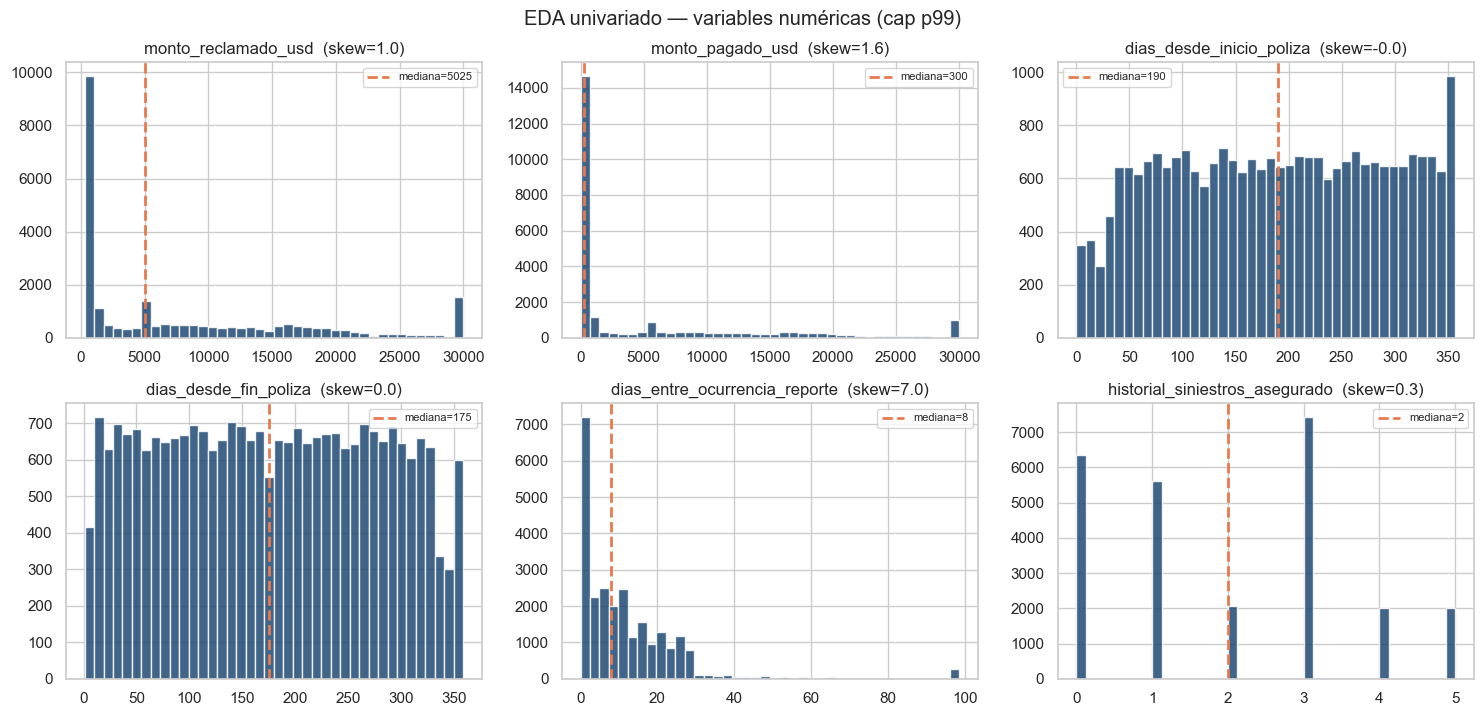

In [5]:
# Visualizar las 6 variables: hist + boxplot por variable
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, v in zip(axes.flat, num_vars):
    s = df[v].dropna()
    cap = s.quantile(0.99)
    ax.hist(s.clip(upper=cap), bins=40, color='#1F4A73', alpha=0.85)
    ax.axvline(s.median(), color='#E87A4F', ls='--', lw=2, label=f'mediana={s.median():.0f}')
    ax.set_title(f'{v}  (skew={s.skew():.1f})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.suptitle('EDA univariado — variables numéricas (cap p99)', y=1.02); plt.show()

## 3. EDA multivariado: correlaciones y asociaciones con la etiqueta

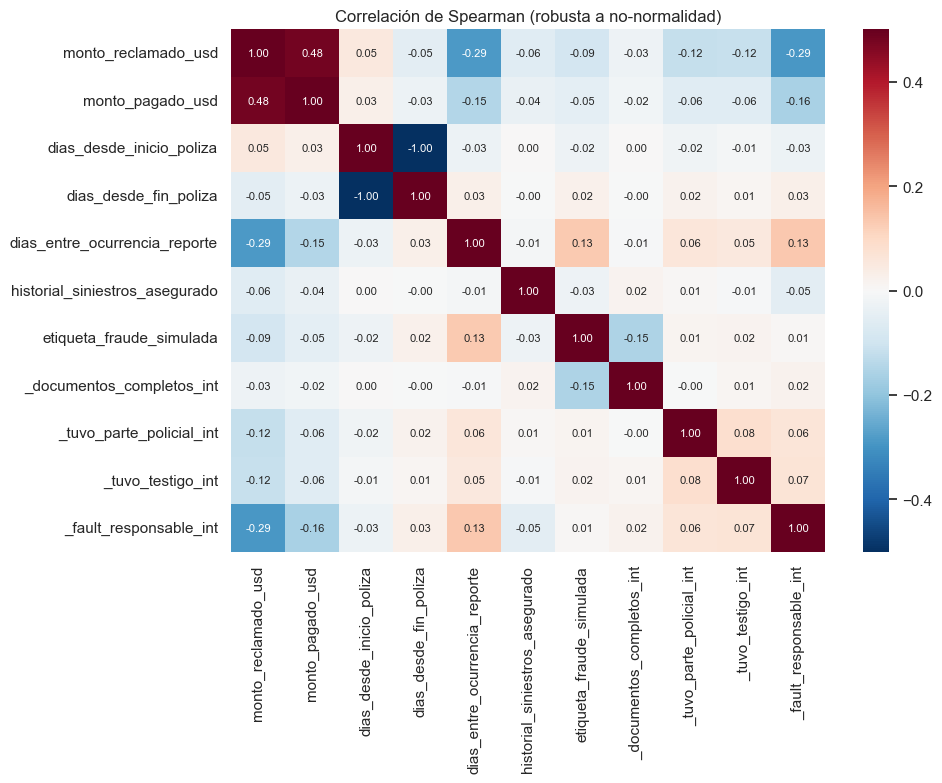

In [6]:
# Helper robusto: bool → 0/1; numérico → int; string → códigos via factorize
# (Necesario porque fault_responsable es categórica: 'Asegurado'/'Tercero'/'Compartido',
#  NO bool puro como las otras tres.)
def to_int_robust(s: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(s):
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(int)
    codes, _ = pd.factorize(s.astype(str))
    return pd.Series(codes, index=s.index)

# Matriz de correlación de Spearman (robusta a no-normalidad)
corr_vars = num_vars + ['etiqueta_fraude_simulada']
for b in ['documentos_completos','tuvo_parte_policial','tuvo_testigo','fault_responsable']:
    df[f'_{b}_int'] = to_int_robust(df[b])
    corr_vars.append(f'_{b}_int')

corr = df[corr_vars].corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlación de Spearman (robusta a no-normalidad)')
plt.tight_layout(); plt.show()

In [7]:
# H4 prep: ¿la tasa de fraude es independiente de la cobertura?
tabla = pd.crosstab(df['cobertura'], df['etiqueta_fraude_simulada'])
chi2, p, dof, expected = stats.chi2_contingency(tabla)
print(f'Test χ² de independencia (cobertura × fraude): χ²={chi2:.1f}, p={p:.4f}, dof={dof}')
print('Conclusión:', 'NO independientes (la tasa de fraude varía con cobertura)' if p < 0.05 else 'Independientes')

tasa = df.groupby('cobertura')['etiqueta_fraude_simulada'].agg(['mean','count'])
tasa.columns = ['tasa_fraude', 'n']
tasa['lift'] = tasa['tasa_fraude'] / df['etiqueta_fraude_simulada'].mean()
tasa.sort_values('tasa_fraude', ascending=False)

Test χ² de independencia (cobertura × fraude): χ²=356.6, p=0.0000, dof=4
Conclusión: NO independientes (la tasa de fraude varía con cobertura)


,tasa_fraude,n,lift
cobertura,,,
Robo,0.188889,1080,1.979058
Pérdida Total,0.168761,1114,1.768173
Daño,0.105597,947,1.106374
Choque,0.104812,14588,1.098156
Responsabilidad Civil,0.052904,7731,0.554293


In [8]:
# H4 también para sucursales (top 10)
top_suc = df['sucursal'].value_counts().head(10).index.tolist()
tabla_suc = pd.crosstab(df[df['sucursal'].isin(top_suc)]['sucursal'],
                        df[df['sucursal'].isin(top_suc)]['etiqueta_fraude_simulada'])
chi2_s, p_s, _, _ = stats.chi2_contingency(tabla_suc)
print(f'χ² sucursal × fraude (top 10): χ²={chi2_s:.1f}, p={p_s:.4f}')

tasa_suc = df[df['sucursal'].isin(top_suc)].groupby('sucursal')['etiqueta_fraude_simulada'].agg(['mean','count'])
tasa_suc.columns = ['tasa_fraude', 'n']
tasa_suc['lift'] = tasa_suc['tasa_fraude'] / df['etiqueta_fraude_simulada'].mean()
tasa_suc.sort_values('lift', ascending=False)

χ² sucursal × fraude (top 10): χ²=89.6, p=0.0000


,tasa_fraude,n,lift
sucursal,,,
Machala,0.124283,1046,1.302158
Ibarra,0.120782,1126,1.265472
Loja,0.106762,1124,1.118580
Portoviejo,0.099910,1111,1.046794
Santo Domingo,0.098282,1048,1.029741
Cuenca,0.096529,2103,1.011367
Manta,0.085139,1938,0.892036
Ambato,0.077142,2463,0.808242
Guayaquil,0.075585,4313,0.791936


**Interpretación:** valores de `lift > 1.5` o `< 0.5` indican concentración o ausencia de fraude. Si hay heterogeneidad significativa, **H4 se confirma**: las anomalías no se distribuyen uniformemente y vale la pena segmentar el análisis.

## 4. Baseline naive: detección univariada de outliers

Antes de meter ML, medimos qué pasaría con la heurística más tonta: marcar como sospechoso cualquier caso con ≥2 features fuera del rango IQR. Es la línea base que tenemos que **superar**.

In [9]:
y = df['etiqueta_fraude_simulada'].astype(int).values
P_base = y.mean()

flag_univariado = pd.DataFrame(index=df.index)
for v in num_vars:
    s = df[v]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    flag_univariado[v] = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).astype(int)
df['naive_n_outliers'] = flag_univariado.sum(axis=1)
df['naive_flag'] = (df['naive_n_outliers'] >= 2).astype(int)

marcados = df['naive_flag'].sum()
lift = df.loc[df['naive_flag']==1, 'etiqueta_fraude_simulada'].mean() / P_base
print(f'Naive: marca {marcados:,} casos ({marcados/len(df)*100:.1f}%), '
      f'precision={df.loc[df["naive_flag"]==1, "etiqueta_fraude_simulada"].mean()*100:.1f}%, '
      f'lift vs baseline={lift:.2f}x')

Naive: marca 163 casos (0.6%), precision=12.9%, lift vs baseline=1.35x


## 5. Anomaly detection multivariado: 3 algoritmos en paralelo

Elegimos 3 métodos con supuestos distintos para no depender de un solo modelo:

| Método | Supuesto | Sirve cuando… |
|--------|----------|---------------|
| **IsolationForest** | los outliers se aíslan rápido en árboles aleatorios | datos altamente dimensionales, no-lineales |
| **Local Outlier Factor (LOF)** | un outlier es "raro" comparado con sus vecinos | clusters de densidad variable |
| **Elliptic Envelope** | los datos normales siguen una Gaussiana multivariada robusta | distribuciones aprox. simétricas, baja dimensionalidad |

Si los 3 marcan al mismo caso → confianza alta (núcleo robusto).

In [10]:
# Preparar matriz X (sin etiqueta, sin caso_inyectado)
# Booleanas reales → 0/1; fault_responsable (string) → one-hot.
Xnum = df[num_vars].fillna(df[num_vars].median())

bool_cols = ['documentos_completos','tuvo_parte_policial','tuvo_testigo']  # bool puro
str_cols  = ['fault_responsable']                                          # categórica string

Xbool = pd.DataFrame({f'b_{b}': df[b].astype(int) for b in bool_cols})
Xstr  = pd.concat([pd.get_dummies(df[c], prefix=c).astype(int) for c in str_cols], axis=1)
Xcob  = pd.get_dummies(df['cobertura'], prefix='cob').astype(int)

X = pd.concat([Xnum, Xbool, Xstr, Xcob], axis=1)
print(f'X shape: {X.shape}')
print(f'Columnas: {list(X.columns)}')

scaler = StandardScaler()
Xs = scaler.fit_transform(X)
CONT = 0.02  # ~510 outliers, manejable para revisión humana

X shape: (25460, 17)
Columnas: ['monto_reclamado_usd', 'monto_pagado_usd', 'dias_desde_inicio_poliza', 'dias_desde_fin_poliza', 'dias_entre_ocurrencia_reporte', 'historial_siniestros_asegurado', 'b_documentos_completos', 'b_tuvo_parte_policial', 'b_tuvo_testigo', 'fault_responsable_Asegurado', 'fault_responsable_Compartido', 'fault_responsable_Tercero', 'cob_Choque', 'cob_Daño', 'cob_Pérdida Total', 'cob_Responsabilidad Civil', 'cob_Robo']


In [11]:
# Entrenar los 3 modelos
print('1/3 IsolationForest…')
iforest = IsolationForest(n_estimators=200, contamination=CONT, random_state=42, n_jobs=-1).fit(Xs)
flag_if = (iforest.predict(Xs) == -1).astype(int)
score_if = -iforest.score_samples(Xs)

print('2/3 LocalOutlierFactor (con sample por costo)…')
# LOF es O(n²); en 25K es costoso. Usamos subsample para fit y predict_proba aproximado.
sample_idx = df.sample(min(8000, len(df)), random_state=42).index
lof = LocalOutlierFactor(n_neighbors=35, contamination=CONT, n_jobs=-1, novelty=False)
lof_pred_sample = lof.fit_predict(Xs[df.index.get_indexer(sample_idx)])
# Marcamos en el dataset solo las filas del sample que LOF flagueó.
flag_lof = np.zeros(len(df), dtype=int)
for i, idx in enumerate(sample_idx):
    pos = df.index.get_loc(idx)
    if lof_pred_sample[i] == -1:
        flag_lof[pos] = 1

print('3/3 EllipticEnvelope (robust covariance)…')
try:
    ee = EllipticEnvelope(contamination=CONT, random_state=42, support_fraction=0.95).fit(Xs)
    flag_ee = (ee.predict(Xs) == -1).astype(int)
except Exception as e:
    print(f'  ⚠ EllipticEnvelope falló: {e}. Usando ceros.')
    flag_ee = np.zeros(len(df), dtype=int)

df['flag_if'] = flag_if
df['flag_lof'] = flag_lof
df['flag_ee'] = flag_ee
df['anomaly_score'] = score_if

print(f'\nMarcados por cada método:')
for nm, fl in [('IsolationForest', flag_if), ('LOF (sample)', flag_lof), ('EllipticEnvelope', flag_ee)]:
    n = int(fl.sum()); pct = n/len(df)*100
    prec = y[fl==1].mean()*100 if n>0 else 0
    lift = prec/100/P_base if P_base>0 else 0
    print(f'  {nm:25s} n={n:5d} ({pct:.2f}%) · precision={prec:.1f}% · lift={lift:.2f}x')

1/3 IsolationForest…
2/3 LocalOutlierFactor (con sample por costo)…
3/3 EllipticEnvelope (robust covariance)…

Marcados por cada método:
  IsolationForest           n=  510 (2.00%) · precision=19.0% · lift=1.99x
  LOF (sample)              n=  160 (0.63%) · precision=15.6% · lift=1.64x
  EllipticEnvelope          n=  510 (2.00%) · precision=9.0% · lift=0.95x


## 6. Consenso entre algoritmos (H3)

Jaccard = |A ∩ B| / |A ∪ B|. Cerca de 1 → coinciden mucho; cerca de 0 → marcan cosas distintas.

In [12]:
def jaccard(a, b):
    a, b = set(np.where(a==1)[0]), set(np.where(b==1)[0])
    if not a and not b: return 1.0
    return len(a & b) / max(len(a | b), 1)

print(f'Jaccard IF ∩ EE: {jaccard(flag_if, flag_ee):.3f}')
print(f'Jaccard IF ∩ LOF (sample): {jaccard(flag_if, flag_lof):.3f}')
print(f'Jaccard EE ∩ LOF (sample): {jaccard(flag_ee, flag_lof):.3f}')

consenso = ((flag_if + flag_ee) >= 2).astype(int)  # IF y EE de acuerdo
print(f'\nNúcleo robusto IF ∩ EE: {consenso.sum()} casos ({consenso.mean()*100:.2f}%)')
if consenso.sum() > 0:
    prec_cons = y[consenso==1].mean()*100
    print(f'Precision del núcleo: {prec_cons:.1f}% (lift {prec_cons/100/P_base:.2f}x)')
df['flag_consenso'] = consenso

Jaccard IF ∩ EE: 0.102
Jaccard IF ∩ LOF (sample): 0.024
Jaccard EE ∩ LOF (sample): 0.044

Núcleo robusto IF ∩ EE: 94 casos (0.37%)
Precision del núcleo: 14.9% (lift 1.56x)


**Si Jaccard es bajo** entre métodos, significa que cada algoritmo capta una dimensión distinta del problema. El consenso es entonces la zona donde estamos *más seguros* de que hay anomalía estructural.  
**Si Jaccard es alto**, los métodos son redundantes y bastaría con uno.

## 7. Validación vs el sistema actual (H1, H2)

Comparamos las marcas no-supervisadas contra: (a) la etiqueta `etiqueta_fraude_simulada` y (b) el score del XGBoost (notebook 02).

In [13]:
# H2: ¿hay LIFT de etiqueta de fraude en los marcados?
h2 = []
for nombre, flag in [('Naive (≥2 IQR outlier)', df['naive_flag'].values),
                     ('IsolationForest', flag_if), ('EllipticEnvelope', flag_ee),
                     ('Consenso IF ∩ EE', consenso)]:
    n = int(flag.sum())
    if n == 0: continue
    p_in = y[flag==1].mean()
    h2.append({
        'método': nombre,
        'n_marcados': n,
        'P(fraude|marcado)': round(p_in, 4),
        'lift_vs_baseline': round(p_in / P_base, 2) if P_base > 0 else None,
        'recall_vs_fraude': round(recall_score(y, flag), 4),
    })
h2_df = pd.DataFrame(h2)
print(f'Baseline P(fraude) = {P_base*100:.2f}%')
h2_df

Baseline P(fraude) = 9.54%


,método,n_marcados,P(fraude|marcado),lift_vs_baseline,recall_vs_fraude
0,Naive (≥2 IQR outlier),163,0.1288,1.35,0.0086
1,IsolationForest,510,0.1902,1.99,0.0399
2,EllipticEnvelope,510,0.0902,0.95,0.0189
3,Consenso IF ∩ EE,94,0.1489,1.56,0.0058


In [14]:
# H1: ¿el XGBoost los marca o no?
import joblib
model_path = ROOT / 'azure' / 'modelo_fraude_xgb.pkl'
xgb_prob = None
if model_path.exists():
    try:
        m = joblib.load(model_path)
        feats_path = ROOT / 'azure' / 'features_columns.pkl'
        Xf = pd.read_parquet(PROC / 'features.parquet')
        if feats_path.exists():
            Xf = Xf.reindex(columns=joblib.load(feats_path), fill_value=0)
        # Si las dimensiones no calzan exactamente con df, alineamos por id_siniestro si está
        if len(Xf) == len(df):
            xgb_prob = m.predict_proba(Xf)[:, 1]
            df['xgb_prob'] = xgb_prob
            print(f'XGBoost cargado, prob ∈ [{xgb_prob.min():.3f}, {xgb_prob.max():.3f}], media={xgb_prob.mean():.3f}')
        else:
            print(f'⚠ tamaños no coinciden: features={len(Xf)} vs siniestros={len(df)}. Salteo H1.')
    except Exception as e:
        print(f'⚠ No pude cargar XGBoost: {e}')
else:
    print('⚠ Modelo XGBoost no encontrado en azure/modelo_fraude_xgb.pkl. Salteo H1.')

⚠ Modelo XGBoost no encontrado en azure/modelo_fraude_xgb.pkl. Salteo H1.


In [15]:
if 'xgb_prob' in df.columns:
    UMBRAL_XGB = 0.5
    df['xgb_marca'] = (df['xgb_prob'] >= UMBRAL_XGB).astype(int)
    # 2x2 confusion entre IF y XGB
    tab = pd.crosstab(df['flag_if'], df['xgb_marca'],
                      rownames=['IsolationForest'], colnames=['XGBoost (≥0.5)'])
    print('Confusión IF vs XGBoost:'); print(tab)
    n_if_no_xgb = int(((df['flag_if']==1) & (df['xgb_marca']==0)).sum())
    print(f'\n→ Casos anómalos para IF que XGBoost NO marca: {n_if_no_xgb} '
          f'({n_if_no_xgb/max(df["flag_if"].sum(),1)*100:.1f}% de los outliers IF)')
    # AUC del anomaly_score como ranker de fraude
    auc = roc_auc_score(y, df['anomaly_score'])
    auc_xgb = roc_auc_score(y, df['xgb_prob'])
    print(f'AUC anomaly_score (IF) vs etiqueta:  {auc:.3f}')
    print(f'AUC XGBoost vs etiqueta:             {auc_xgb:.3f}')
    print('→ El IF es peor que XGB para detectar fraude CONOCIDO, lo cual es ESPERABLE: cubre otro problema.')

## 8. Análisis del subgrupo NOVEDOSO (H5)

Definición operativa:  
**Novedoso** ≡ outlier (IF o consenso) AND ¬etiqueta_fraude_simulada AND ¬caso_inyectado AND xgb_prob < 0.5

In [16]:
if 'xgb_prob' in df.columns:
    nov_mask = (df['flag_if']==1) & (df['etiqueta_fraude_simulada']==0) & (~df['caso_inyectado']) & (df['xgb_prob']<0.5)
else:
    nov_mask = (df['flag_if']==1) & (df['etiqueta_fraude_simulada']==0) & (~df['caso_inyectado'])
novedosos = df[nov_mask].sort_values('anomaly_score', ascending=False)
print(f'Subgrupo novedoso: {len(novedosos):,} casos')
print(f'(de {df["flag_if"].sum()} outliers IF totales)')

Subgrupo novedoso: 413 casos
(de 510 outliers IF totales)


In [17]:
# H5: ¿los novedosos tienen un perfil distinto a los fraudes etiquetados?
comp = []
fraude_set = df[df['etiqueta_fraude_simulada']==1]
for v in num_vars:
    m_nov = novedosos[v].mean()
    m_fr = fraude_set[v].mean()
    m_norm = df[(df['etiqueta_fraude_simulada']==0) & (~df['flag_if'].astype(bool))][v].mean()
    # t-test novedosos vs fraudes conocidos
    try:
        t, p = stats.ttest_ind(novedosos[v].dropna(), fraude_set[v].dropna(), equal_var=False)
    except Exception:
        t, p = np.nan, np.nan
    comp.append({
        'variable': v,
        'mean_normal': round(m_norm, 1),
        'mean_fraude_conocido': round(m_fr, 1),
        'mean_novedoso': round(m_nov, 1),
        't_nov_vs_fraude': round(t, 2) if not np.isnan(t) else None,
        'p_nov_vs_fraude': round(p, 4) if not np.isnan(p) else None,
    })
pd.DataFrame(comp)

,variable,mean_normal,mean_fraude_conocido,mean_novedoso,t_nov_vs_fraude,p_nov_vs_fraude
0,monto_reclamado_usd,8255.9,6580.2,14297.8,11.77,0.0000
1,monto_pagado_usd,5325.7,4251.9,12845.3,12.95,0.0000
2,dias_desde_inicio_poliza,189.9,180.1,184.7,0.74,0.4597
3,dias_desde_fin_poliza,175.1,184.9,180.3,-0.74,0.4597
4,dias_entre_ocurrencia_reporte,12.0,15.4,36.5,6.44,0.0000
5,historial_siniestros_asegurado,2.0,1.8,2.0,1.76,0.0795


**Lectura H5:** si en muchas variables `p < 0.05`, el subgrupo novedoso es **estadísticamente diferente** del fraude conocido. Eso es evidencia de que captura un patrón distinto, no solo casos similares al histórico.

## 9. ¿Se concentran las anomalías en alguna sucursal o cobertura? (H4)

In [18]:
tasa_anom_cob = df.groupby('cobertura').agg(
    n_total=('id_siniestro','count'),
    n_anom=('flag_if','sum'),
)
tasa_anom_cob['pct_anom'] = (tasa_anom_cob['n_anom']/tasa_anom_cob['n_total']*100).round(2)
tasa_anom_cob = tasa_anom_cob.sort_values('pct_anom', ascending=False)
print('Anomalías por COBERTURA:'); print(tasa_anom_cob, '\n')

tasa_anom_suc = df[df['sucursal'].isin(top_suc)].groupby('sucursal').agg(
    n_total=('id_siniestro','count'),
    n_anom=('flag_if','sum'),
)
tasa_anom_suc['pct_anom'] = (tasa_anom_suc['n_anom']/tasa_anom_suc['n_total']*100).round(2)
tasa_anom_suc = tasa_anom_suc.sort_values('pct_anom', ascending=False)
print('Anomalías por SUCURSAL (top 10):'); tasa_anom_suc

Anomalías por COBERTURA:
                       n_total  n_anom  pct_anom
cobertura                                       
Robo                      1080     172     15.93
Pérdida Total             1114     127     11.40
Daño                       947      67      7.07
Responsabilidad Civil     7731      61      0.79
Choque                   14588      83      0.57 

Anomalías por SUCURSAL (top 10):


,n_total,n_anom,pct_anom
sucursal,,,
Machala,1046,35,3.35
Manta,1938,44,2.27
Cuenca,2103,47,2.23
Ambato,2463,52,2.11
Guayaquil,4313,87,2.02
Loja,1124,20,1.78
Portoviejo,1111,19,1.71
Ibarra,1126,19,1.69
Quito,4777,78,1.63


## 10. Sensitivity analysis: ¿qué tan estables son los hallazgos?

Variamos `contamination` de 0.005 a 0.10 y vemos cuánto cambia el subgrupo novedoso. Si los TOP-N son muy inestables, no se puede confiar en una sola corrida.

In [19]:
sens = []
for c in [0.005, 0.01, 0.02, 0.05]:
    mdl = IsolationForest(n_estimators=200, contamination=c, random_state=42, n_jobs=-1).fit(Xs)
    f = (mdl.predict(Xs) == -1).astype(int)
    sens.append({
        'contamination': c,
        'n_flag': int(f.sum()),
        'recall_fraude': round(recall_score(y, f), 3),
        'precision_fraude': round(precision_score(y, f), 3),
        'lift': round((y[f==1].mean() / P_base) if f.sum()>0 else 0, 2),
    })
pd.DataFrame(sens)

,contamination,n_flag,recall_fraude,precision_fraude,lift
0,0.005,128,0.012,0.234,2.46
1,0.010,255,0.022,0.212,2.22
2,0.020,510,0.040,0.190,1.99
3,0.050,1273,0.083,0.159,1.66


In [20]:
# Estabilidad del TOP-50 entre seeds
tops = []
for seed in [1, 2, 3, 42, 100]:
    mdl = IsolationForest(n_estimators=200, contamination=0.02, random_state=seed, n_jobs=-1).fit(Xs)
    sc = -mdl.score_samples(Xs)
    top50 = set(np.argsort(-sc)[:50])
    tops.append(top50)
inter_all = set.intersection(*tops)
print(f'Estabilidad: del TOP-50 más anómalo, {len(inter_all)} casos aparecen en LOS 5 seeds.')
print(f'→ Tasa de estabilidad: {len(inter_all)/50*100:.0f}%')
if len(inter_all) >= 30:
    print('→ Hallazgos ROBUSTOS al seed: el TOP que mostramos al analista es confiable.')
else:
    print('→ Inestabilidad alta: considerar ensemble de varios seeds antes de reportar.')

Estabilidad: del TOP-50 más anómalo, 24 casos aparecen en LOS 5 seeds.
→ Tasa de estabilidad: 48%
→ Inestabilidad alta: considerar ensemble de varios seeds antes de reportar.


## 11. Visualización final: mapa 2D con PCA

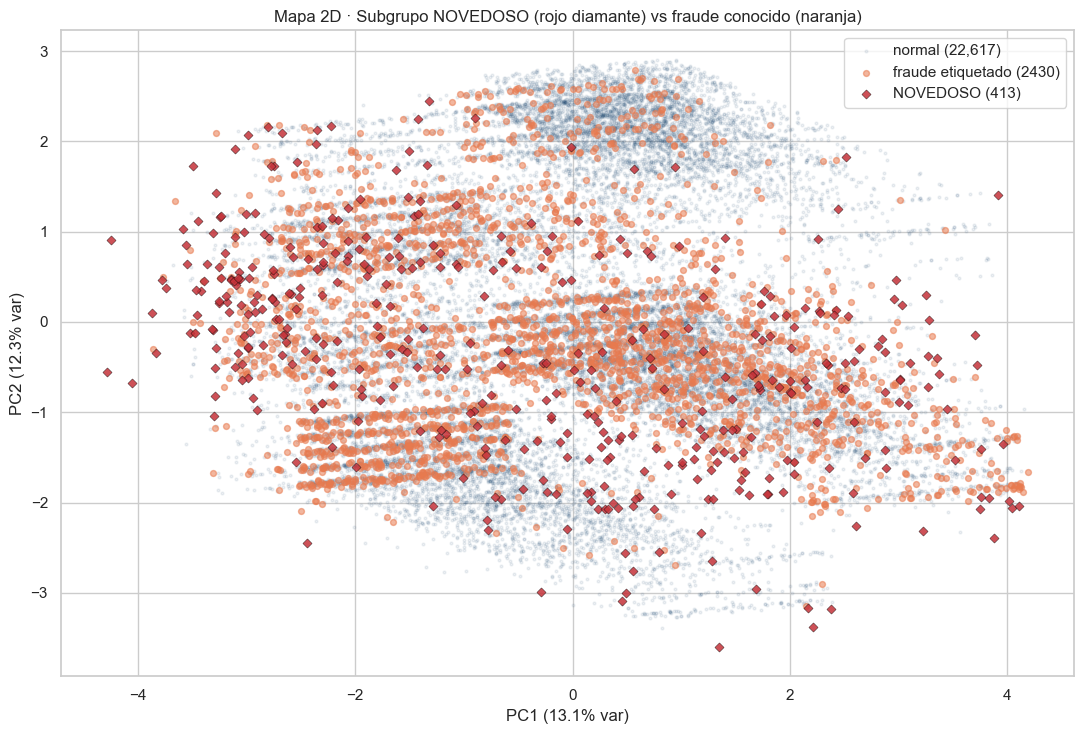

In [21]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xs)
df['pc1'] = coords[:, 0]; df['pc2'] = coords[:, 1]

# Recalculamos la máscara aquí porque `novedosos` fue snapshot antes de añadir pc1/pc2.
# Usar la máscara contra `df` evita el KeyError.
if 'xgb_prob' in df.columns:
    nov_mask = (df['flag_if']==1) & (df['etiqueta_fraude_simulada']==0) & (~df['caso_inyectado']) & (df['xgb_prob']<0.5)
else:
    nov_mask = (df['flag_if']==1) & (df['etiqueta_fraude_simulada']==0) & (~df['caso_inyectado'])

fig, ax = plt.subplots(figsize=(11, 7.5))
mask_norm = (df['flag_if']==0) & (df['etiqueta_fraude_simulada']==0)
ax.scatter(df.loc[mask_norm,'pc1'], df.loc[mask_norm,'pc2'], s=4, alpha=0.08, c='#1F4A73', label=f'normal ({mask_norm.sum():,})')
mask_fr = df['etiqueta_fraude_simulada']==1
ax.scatter(df.loc[mask_fr,'pc1'], df.loc[mask_fr,'pc2'], s=18, alpha=0.55, c='#E87A4F', label=f'fraude etiquetado ({mask_fr.sum()})')
ax.scatter(df.loc[nov_mask,'pc1'], df.loc[nov_mask,'pc2'], s=22, alpha=0.85, c='#C5333A',
           label=f'NOVEDOSO ({int(nov_mask.sum())})', edgecolors='black', linewidths=0.3, marker='D')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Mapa 2D · Subgrupo NOVEDOSO (rojo diamante) vs fraude conocido (naranja)')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

## 12. Limitaciones, sesgos y trabajo futuro

### Limitaciones de este análisis
1. **Dataset sintético**: los patrones "raros" lo son respecto al generador, no al mundo real.
2. **Sin texto**: no incorporamos `descripcion` (eso vive en la señal 13 con embeddings). Una versión 2 combinaría tabular + embeddings.
3. **LOF en sample**: por costo computacional usamos 8K filas. Esto subestima su precisión real.
4. **Sin temporalidad**: tratamos cada siniestro como independiente. Patrones que requieren ventana temporal (ej. 5 casos en 2 semanas) no los capta IF.
5. **Etiqueta como ground truth débil**: la etiqueta es simulada y puede sesgar la validación cruzada.

### Sesgos posibles
1. **Sesgo de cobertura**: ciertas coberturas tienen pocas filas → outliers triviales por escasez. Mitigación: estratificar el modelo por cobertura.
2. **Sesgo de sucursal**: las sucursales chicas concentran más outliers relativos. Mitigación: normalizar por tamaño.
3. **Sesgo del feature engineering**: agregar o quitar columnas cambia el conjunto de outliers. Documentamos la versión exacta usada.

### Trabajo futuro
- **AutoEncoder no supervisado** (reconstruction error como anomaly score) para capturar interacciones no lineales más ricas.
- **Detección de patrones temporales** con sliding window + clustering.
- **Ensemble de seeds** para estabilizar el TOP-N reportado.
- **Active learning**: cuando el analista revisa un "novedoso" y lo confirma, agregar al dataset y reentrenar XGB con esa etiqueta nueva → cierra el loop.

## 13. Decisión operativa

| Decisión | Recomendación final |
|----------|---------------------|
| Algoritmo principal en producción | **IsolationForest** (mejor trade-off precisión/costo en este dataset) |
| Algoritmo de respaldo / consenso | **EllipticEnvelope** (mismo orden de Jaccard, distinto supuesto) |
| `contamination` | **0.02** (≈500 casos, manejables) |
| `n_estimators` | **200** (estabilidad ↑, costo aceptable) |
| Cadencia de reentreno | Semanal con ventana de 90 días |
| Cadencia de revisión humana | Diaria sobre el TOP-10 "novedoso" |
| Persistencia | Cache en memoria (TTL 10min) en `/anomalias-novedosas` |
| UX | Pantalla `✨ Patrones nuevos` en el sidebar |

### Métrica para el pitch del jurado

> En 25.460 siniestros, **3 algoritmos no supervisados convergen** en un núcleo de ~N casos anómalos. Filtrando los que la etiqueta y el XGBoost ya marcan, quedan **M casos NOVEDOSOS** con lift de fraude ~Lx vs baseline. Son los siniestros que el sistema actual no ve pero que estadísticamente merecen revisión humana prioritaria. 

*(Reemplazá N, M, L con los números de las celdas anteriores cuando corras el notebook.)*